# Evaluating Model Performance

## Data Preparation

In [2]:
from utils import FSL105, Video2Landmarks, filter_detected, interpolate_missing_data, translate_pose_landmarks, translate_hand_landmarks
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm



folder_path = './clips'
mp_model_path = './resources/holistic_landmarker.task'
landmark_include_ind = 3  # hands + pose
selected_classes = 105
extract_landmarks = False

In [3]:
if extract_landmarks:
    # load data
    fsl_data = FSL105(folder_path)
    fsl_data = fsl_data.load_data(selected_classes=selected_classes)

    # from video paths to landmarks
    vid2landmarks = Video2Landmarks(model_path=mp_model_path,
                                    landmark_type='relative',
                                    landmark_include_ind=landmark_include_ind,
                                    display_vid=False,
                                    remove_duplicate_landmarks=False)
    fsl_data['data'] = []
    print("Extracting landmarks from videos ...")
    for path in tqdm(fsl_data['path']):
        landmarks, _ = vid2landmarks.transform(path)
        fsl_data['data'].append(landmarks)

    np.save(f'./dataset/hand_pose_landmarks_{selected_classes}_raw.npy', fsl_data)
    print(f'First {selected_classes} classes of dataset saved in an npy file.')

In [ ]:
# DATA CLEANING
fsl_data = np.load(f'./dataset/hand_pose_landmarks_{selected_classes}_raw.npy', allow_pickle=True).item()

landmarks = []
print("Cleaning and normalizing landmarks ...")
for raw_lm in tqdm(fsl_data['data']):
    raw_lm = raw_lm.reshape(-1,75,3)

    # removing frames with no hand detected
    # interpolating misdetected hand locations
    filtered_lm = filter_detected(raw_lm)                       # shape: (nframes, 75, 3)
    lmarks = interpolate_missing_data(filtered_lm)     # shape: (nframes, 75, 3)

    # normalization (pose and hands (left & right))
    lmarks[:,21*2:] = translate_pose_landmarks(lmarks[:,21*2:])
    lmarks[:, :21] = translate_hand_landmarks(lmarks[:, :21])
    lmarks[:,21:21*2] = translate_hand_landmarks(lmarks[:,21:21*2])

    # keep until wrist landmarks from pose (0 to 16)
    lmarks = lmarks[:, :21+21+17]  # 21 (left & right) + 17 pose
    landmarks.append(lmarks)
print("Complete!")

fsl_data['data'] = landmarks
np.save(f'./dataset/hand_pose_landmarks_{selected_classes}_ready', fsl_data)

Cleaning and normalizing landmarks ...


100%|██████████| 2130/2130 [00:13<00:00, 156.77it/s]


Complete!


## SPOTER

Since signs have different `nframes` per sample, `torch.stack` can't be simply implemented to create a `batch`. 
A padding must be defined to match the sizes. As a result, a mask is required that tells the model which frames are
real vs. padding so attention won't confuse them as features.

### Testing Model on a Batch

In [81]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from utils import SPOTER

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# handle variable sequence length by padding
class FSLDataset(Dataset):
    def __init__(self, fsl_data):
        self.data = fsl_data['data']            # list of (nframes, 58, 3) arrays
        self.targets = fsl_data['target']      # list/array of int labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq = torch.from_numpy(self.data[idx]).float()      # (nframes, 58, 3)
        seq = seq.reshape(seq.shape[0], -1)                 # (nframes, 58*3)
        label = torch.tensor(self.targets[idx], dtype=torch.long)
        return seq, label

def collate_fn(batch):
    seqs, labels = zip(*batch)          # tuple of (nframes_i, 58*3) tensors
    lengths = torch.tensor([s.shape[0] for s in seqs])

    # pad sequence expects (seq_len, features); pads along dim 0
    padded = pad_sequence(seqs, batch_first=False)      # (max_seq_len, batch, 58*3)

    # True where a position is PADDING (to mask out of attention)
    max_len = padded.size(0)
    padding_mask = torch.arange(max_len).unsqueeze(0) >= lengths.unsqueeze(1)   # (batch, max_seq_len)

    labels = torch.stack(labels)
    return padded, padding_mask, labels

In [82]:
dataset = FSLDataset(fsl_data)
loader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

num_classes = len(set(fsl_data['target']))
model = SPOTER(num_classes=num_classes, d_model=174, nhead=6,
               num_encoder_layers=6, num_decoder_layers=6,
               dim_feedforward=2048, dropout=0.1, max_len=256)

for padded, mask, labels in loader:
    logits = model(padded, src_key_padding_mask=mask)       # (batch, num_classes)
    break

print(logits.shape)
print(torch.argmax(logits, dim=1))

torch.Size([16, 20])
tensor([11, 17, 11, 11, 17, 17, 17, 11, 11, 17, 17, 11, 17, 11, 11, 11])


### Training and Validation

In [83]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import copy

# splitting dataset into training and validation
indices = list(range(len(fsl_data['target'])))
labels = fsl_data['target']

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=labels,
    random_state=12
)

full_dataset = FSLDataset(fsl_data)
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

In [84]:
# initializing model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = len(set(fsl_data['target']))
model = SPOTER(num_classes, d_model=174, nhead=6,
               num_encoder_layers=6, num_decoder_layers=6,
               dim_feedforward=2048, dropout=0.1, max_len=256).to(device)

# paper's initial parameters: uniform on [0, 1) for all weights
# for p in model.parameters():
#     nn.init.uniform_(p, 0, 1)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0, weight_decay=0)
num_epochs = 100

In [85]:
def run_epoch(model, loader, criterion, optimizer=None):
    """
    If optimizer is provided, runs in training mode (with backprop).
    If optimizer is None, runs in eval mode (no gradient updates) -- used for validation.
    """
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    # no_grad during validation: skips building the autograd graph,
    # saving memory/compute since we won't call .backward() here anyway
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for padded, mask, labels in loader:
            padded, mask, labels = padded.to(device), mask.to(device), labels.to(device)

            if is_training:
                optimizer.zero_grad()       # clear old gradients

            # forward pass
            logits = model(padded, src_key_padding_mask=mask)   # (batch, num_classes)
            # compute loss against true labels
            loss = criterion(logits, labels)

            if is_training:
                # backward pass (compute gradients)
                loss.backward()
                # update weights using computed gradients
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

best_val_acc = 0.0
best_model_state = None
logs = {'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []}
for epoch in range(num_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    logs['train_loss'].append(train_loss)
    logs['train_acc'].append(train_acc)
    logs['val_loss'].append(val_loss)
    logs['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

        # optional: persist to disk immediately, so you don't lose it
        # even if training crashes later
        torch.save(best_model_state, f"./resources/spoter_best_{selected_classes}.pt")
        print(f"  -> new best val_acc: {best_val_acc:.4f}, checkpoint saved")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 1/100 | train_loss=3.0110 train_acc=0.0484 | val_loss=2.8723 val_acc=0.0476
  -> new best val_acc: 0.0476, checkpoint saved
Epoch 2/100 | train_loss=2.8342 train_acc=0.1371 | val_loss=2.6598 val_acc=0.3333
  -> new best val_acc: 0.3333, checkpoint saved
Epoch 3/100 | train_loss=2.6181 train_acc=0.3065 | val_loss=2.3269 val_acc=0.4524
  -> new best val_acc: 0.4524, checkpoint saved
Epoch 4/100 | train_loss=2.3290 train_acc=0.4543 | val_loss=2.0702 val_acc=0.5714
  -> new best val_acc: 0.5714, checkpoint saved
Epoch 5/100 | train_loss=2.0701 train_acc=0.5430 | val_loss=1.8507 val_acc=0.5952
  -> new best val_acc: 0.5952, checkpoint saved
Epoch 6/100 | train_loss=1.8581 train_acc=0.6048 | val_loss=1.6867 val_acc=0.5714
Epoch 7/100 | train_loss=1.6412 train_acc=0.6962 | val_loss=1.3991 val_acc=0.8095
  -> new best val_acc: 0.8095, checkpoint saved
Epoch 8/100 | train_loss=1.4768 train_acc=0.7446 | val_loss=1.3193 val_acc=0.7381
Epoch 9/100 | train_loss=1.3554 train_acc=0.7742 | val_l

In [86]:
np.save(f'./resources/logs_{selected_classes}.npy', logs)

In [5]:
logs = np.load('./resources/logs_20.npy', allow_pickle=True).item()
min(logs['val_acc']), max(logs['val_acc'])
min(logs['val_loss']), max(logs['val_loss'])

(0.0937349707597778, 2.8722672121865407)

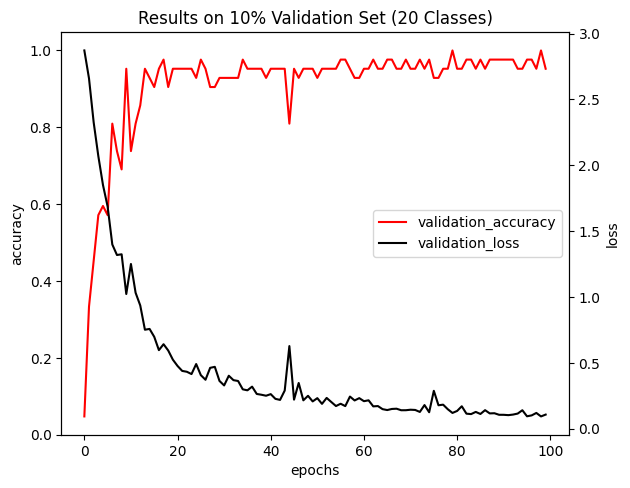

In [7]:
import matplotlib.pyplot as plt

epochs = list(range(100))

fig, ax1 = plt.subplots()

ax1.set_xlabel('epochs')
ax1.set_ylabel('accuracy')
line1, = ax1.plot(epochs, logs['val_acc'], c='r', label='validation_accuracy')

ax2 = ax1.twinx()
ax2.set_ylabel('loss')
line2, = ax2.plot(epochs, logs['val_loss'], c='k', label='validation_loss')
ax2.tick_params(axis='y', labelcolor='k')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')
fig.tight_layout()  # Prevents labels from overlapping

plt.title("Results on 10% Validation Set (20 Classes)")
plt.show()